In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/raw/features_30_sec.csv')

X = df.drop(columns=['filename', 'label'])
y = df['label']

print("X shape:", X.shape)
print("Classes:", y.unique())

X shape: (1000, 58)
Classes: <StringArray>
[    'blues', 'classical',   'country',     'disco',    'hiphop',      'jazz',
     'metal',       'pop',    'reggae',      'rock']
Length: 10, dtype: str


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

Label mapping:
  blues → 0
  classical → 1
  country → 2
  disco → 3
  hiphop → 4
  jazz → 5
  metal → 6
  pop → 7
  reggae → 8
  rock → 9


In [ ]:

print("Feature ranges before scaling:")
print(X.describe().loc[['min', 'max']].T.head(10))

Feature ranges before scaling:
                                   min           max
length                   660000.000000  6.758080e+05
chroma_stft_mean              0.171939  6.636847e-01
chroma_stft_var               0.044555  1.081115e-01
rms_mean                      0.005276  3.979734e-01
rms_var                       0.000004  2.767948e-02
spectral_centroid_mean      570.040355  4.435244e+03
spectral_centroid_var      7911.251394  3.036843e+06
spectral_bandwidth_mean     898.066208  3.509646e+03
spectral_bandwidth_var    10787.185064  6.947848e+05
rolloff_mean                749.140636  8.677673e+03


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("After scaling:")
print(X_scaled.describe().loc[['mean', 'std']].T.head(10))


After scaling:
                                 mean     std
length                  -1.099920e-14  1.0005
chroma_stft_mean        -4.831691e-16  1.0005
chroma_stft_var         -1.882938e-15  1.0005
rms_mean                -4.973799e-16  1.0005
rms_var                 -9.947598e-17  1.0005
spectral_centroid_mean   1.705303e-16  1.0005
spectral_centroid_var    9.947598e-17  1.0005
spectral_bandwidth_mean -4.405365e-16  1.0005
spectral_bandwidth_var   1.563194e-16  1.0005
rolloff_mean            -1.847411e-16  1.0005


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Val size:  ", X_val.shape)
print("Test size: ", X_test.shape)

Train size: (700, 58)
Val size:   (150, 58)
Test size:  (150, 58)


/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12486/1078370977.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(le.classes_, rotation=45)
/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12486/1078370977.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(le.classes_, rotation=45)
/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12486/1078370977.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(le.classes_, rotation=45)


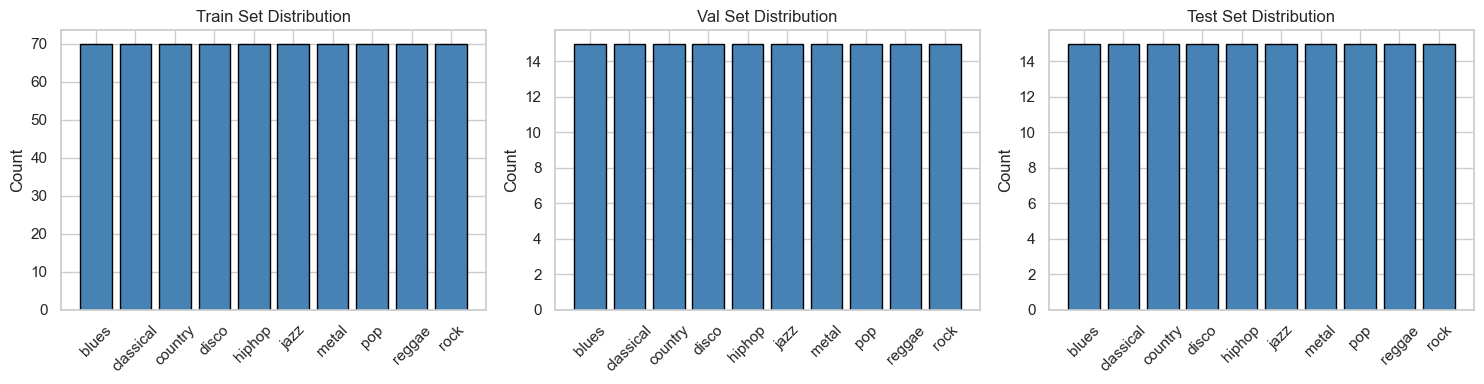

In [7]:
#Verify split is balanced
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split, name in zip(axes, [y_train, y_val, y_test], ['Train', 'Val', 'Test']):
    counts = pd.Series(split).value_counts().sort_index()
    ax.bar(le.classes_, counts, color='steelblue', edgecolor='black')
    ax.set_title(f'{name} Set Distribution')
    ax.set_xticklabels(le.classes_, rotation=45)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/figures/split_distribution.png')
plt.show()

In [ ]:
# Save splits so every subsequent notebook can just load these instead of redoing preprocessing each time
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_val_df   = pd.DataFrame(X_val,   columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

X_train_df['label'] = y_train
X_val_df['label']   = y_val
X_test_df['label']  = y_test

X_train_df.to_csv('../data/processed/train.csv', index=False)
X_val_df.to_csv('../data/processed/val.csv',     index=False)
X_test_df.to_csv('../data/processed/test.csv',   index=False)

print("Saved train/val/test to data/processed/")

Saved train/val/test to data/processed/


## Summary

- Labels encoded using LabelEncoder (blues=0 through rock=9)
- Features scaled using StandardScaler — all features now have mean≈0, std≈1
- Dataset split 70/15/15 into train/val/test with stratification to preserve class balance
- Processed splits saved to data/processed/ for use in all subsequent notebooks